# Лабораторная работа №5.4

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  

**Тема:** Алгоритмы Actor-Critic

In [1]:
# Импорт необходимых библиотек для выполнения лабораторной работы

try:
    import gymnasium as gym
except ImportError:
    !pip install gymnasium -q
    import gymnasium as gym

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Библиотеки успешно импортированы")
print("Версия Gymnasium:", gym.__version__)
print("Версия NumPy:", np.__version__)
print("Версия PyTorch:", torch.__version__)
print("Используемое устройство:", device)

Библиотеки успешно импортированы
Версия Gymnasium: 1.3.0
Версия NumPy: 2.0.2
Версия PyTorch: 2.11.0+cu128
Используемое устройство: cuda


In [2]:
# Создание среды CartPole-v1 и вывод основных характеристик

env = gym.make("CartPole-v1")

print("Среда:", "CartPole-v1")

print("\nПространство наблюдений:")
print(env.observation_space)

print("\nПространство действий:")
print(env.action_space)

print("\nКоличество признаков состояния:", env.observation_space.shape[0])
print("Количество действий:", env.action_space.n)

state, info = env.reset()

print("\nНачальное состояние:")
print(state)

print("\nОписание признаков состояния:")
print("1. Положение тележки")
print("2. Скорость тележки")
print("3. Угол наклона шеста")
print("4. Угловая скорость шеста")

Среда: CartPole-v1

Пространство наблюдений:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Пространство действий:
Discrete(2)

Количество признаков состояния: 4
Количество действий: 2

Начальное состояние:
[ 0.03655644 -0.01352966 -0.02239741  0.02603528]

Описание признаков состояния:
1. Положение тележки
2. Скорость тележки
3. Угол наклона шеста
4. Угловая скорость шеста


In [3]:
# Создание нейронной сети Actor-Critic

class ActorCriticNetwork(nn.Module):
    '''
    Нейронная сеть Actor-Critic.
    Actor формирует вероятности действий.
    Critic оценивает ценность состояния.
    '''

    def __init__(self, state_dim, action_dim):
        super(ActorCriticNetwork, self).__init__()

        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        self.actor = nn.Sequential(
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )

        self.critic = nn.Linear(128, 1)


    def forward(self, state):
        '''
        Прямой проход сети.
        '''
        features = self.shared_layers(state)
        action_probs = self.actor(features)
        state_value = self.critic(features)
        return action_probs, state_value


state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

actor_critic_net = ActorCriticNetwork(state_dim, action_dim).to(device)

sample_state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
sample_action_probs, sample_state_value = actor_critic_net(sample_state)

print("Нейронная сеть Actor-Critic успешно создана")
print("Количество признаков состояния:", state_dim)
print("Количество действий:", action_dim)
print("Размер входного состояния:", sample_state.shape)
print("Вероятности действий:", sample_action_probs.detach().cpu().numpy())
print("Оценка ценности состояния:", sample_state_value.item())

print("\nАрхитектура сети:")
print(actor_critic_net)

Нейронная сеть Actor-Critic успешно создана
Количество признаков состояния: 4
Количество действий: 2
Размер входного состояния: torch.Size([1, 4])
Вероятности действий: [[0.5715286 0.4284714]]
Оценка ценности состояния: -0.12876655161380768

Архитектура сети:
ActorCriticNetwork(
  (shared_layers): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (actor): Sequential(
    (0): Linear(in_features=128, out_features=2, bias=True)
    (1): Softmax(dim=-1)
  )
  (critic): Linear(in_features=128, out_features=1, bias=True)
)


In [4]:
# Создание агента Actor-Critic

class ActorCriticAgent:
    '''
    Агент Actor-Critic для обучения в среде CartPole-v1.
    '''

    def __init__(self, env, model, gamma=0.99, lr=0.001):
        self.env = env
        self.model = model
        self.gamma = gamma

        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        self.episodes_reward = []
        self.episodes_steps = []
        self.actor_losses = []
        self.critic_losses = []


    def select_action(self, state):
        '''
        Выбор действия на основе вероятностей, сформированных Actor.
        '''
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        action_probs, state_value = self.model(state_tensor)
        distribution = Categorical(action_probs)
        action = distribution.sample()

        log_prob = distribution.log_prob(action)

        return action.item(), log_prob, state_value


    def print_info(self):
        '''
        Вывод основной информации об агенте.
        '''
        print("Агент Actor-Critic успешно создан")
        print("Среда:", "CartPole-v1")
        print("Количество признаков состояния:", self.env.observation_space.shape[0])
        print("Количество действий:", self.env.action_space.n)
        print("Gamma:", self.gamma)
        print("Оптимизатор:", self.optimizer)


ac_agent = ActorCriticAgent(env, actor_critic_net)

ac_agent.print_info()

Агент Actor-Critic успешно создан
Среда: CartPole-v1
Количество признаков состояния: 4
Количество действий: 2
Gamma: 0.99
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [5]:
# Обучение агента Actor-Critic

def train_actor_critic(agent, num_episodes=500, max_steps=500):
    '''
    Обучение агента Actor-Critic в среде CartPole-v1.
    '''
    start_time = time.time()

    for episode in tqdm(range(num_episodes)):
        state, info = agent.env.reset()

        total_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            action, log_prob, state_value = agent.select_action(state)

            next_state, reward, terminated, truncated, info = agent.env.step(action)
            done = terminated or truncated

            next_state_tensor = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                _, next_state_value = agent.model(next_state_tensor)

            reward_tensor = torch.tensor([[reward]], dtype=torch.float32).to(device)
            done_tensor = torch.tensor([[done]], dtype=torch.float32).to(device)

            td_target = reward_tensor + agent.gamma * next_state_value * (1 - done_tensor)
            advantage = td_target - state_value

            actor_loss = -log_prob * advantage.detach()
            critic_loss = advantage.pow(2)
            total_loss = actor_loss + critic_loss

            agent.optimizer.zero_grad()
            total_loss.backward()
            agent.optimizer.step()

            agent.actor_losses.append(actor_loss.item())
            agent.critic_losses.append(critic_loss.item())

            state = next_state
            total_reward += reward
            steps += 1

        agent.episodes_reward.append(total_reward)
        agent.episodes_steps.append(steps)

        if (episode + 1) % 50 == 0:
            print(
                "Эпизод:", episode + 1,
                "| Награда:", total_reward,
                "| Шаги:", steps,
                "| Средняя награда за последние 50 эпизодов:",
                np.mean(agent.episodes_reward[-50:])
            )

    training_time = time.time() - start_time

    print("\nОбучение Actor-Critic завершено")
    print("Количество эпизодов:", num_episodes)
    print("Время обучения:", training_time)
    print("Средняя награда за последние 50 эпизодов:", np.mean(agent.episodes_reward[-50:]))
    print("Среднее количество шагов за последние 50 эпизодов:", np.mean(agent.episodes_steps[-50:]))
    print("Максимальная награда:", np.max(agent.episodes_reward))

    return training_time


training_time = train_actor_critic(ac_agent, num_episodes=500, max_steps=500)

 11%|█         | 53/500 [00:04<00:34, 12.97it/s]

Эпизод: 50 | Награда: 11.0 | Шаги: 11 | Средняя награда за последние 50 эпизодов: 11.14


 20%|██        | 102/500 [00:10<00:42,  9.47it/s]

Эпизод: 100 | Награда: 27.0 | Шаги: 27 | Средняя награда за последние 50 эпизодов: 25.72


 30%|███       | 150/500 [00:20<00:58,  5.95it/s]

...

Эпизод: 400 | Награда: 14.0 | Шаги: 14 | Средняя награда за последние 50 эпизодов: 349.06


 90%|█████████ | 450/500 [03:22<00:58,  1.17s/it]

Эпизод: 450 | Награда: 500.0 | Шаги: 500 | Средняя награда за последние 50 эпизодов: 185.76


100%|██████████| 500/500 [04:05<00:00,  2.04it/s]

Эпизод: 500 | Награда: 195.0 | Шаги: 195 | Средняя награда за последние 50 эпизодов: 250.1

Обучение Actor-Critic завершено
Количество эпизодов: 500
Время обучения: 245.32301926612854
Средняя награда за последние 50 эпизодов: 250.1
Среднее количество шагов за последние 50 эпизодов: 250.1
Максимальная награда: 500.0


In [6]:
# Проверка обученного агента Actor-Critic

def evaluate_actor_critic(agent, episodes_count=20, max_steps=500):
    '''
    Проверка качества обученного агента Actor-Critic.
    '''
    test_rewards = []
    test_steps = []

    for episode in range(episodes_count):
        state, info = agent.env.reset()

        total_reward = 0
        steps = 0
        done = False

        while not done and steps < max_steps:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                action_probs, state_value = agent.model(state_tensor)
                action = torch.argmax(action_probs).item()

            next_state, reward, terminated, truncated, info = agent.env.step(action)
            done = terminated or truncated

            state = next_state
            total_reward += reward
            steps += 1

        test_rewards.append(total_reward)
        test_steps.append(steps)

        print(
            "Тестовый эпизод:", episode + 1,
            "| Награда:", total_reward,
            "| Шаги:", steps
        )

    print("\nПроверка обученного агента Actor-Critic завершена")
    print("Количество тестовых эпизодов:", episodes_count)
    print("Средняя тестовая награда:", np.mean(test_rewards))
    print("Среднее количество шагов:", np.mean(test_steps))
    print("Минимальная награда:", np.min(test_rewards))
    print("Максимальная награда:", np.max(test_rewards))

    return test_rewards, test_steps


test_rewards, test_steps = evaluate_actor_critic(ac_agent, episodes_count=20, max_steps=500)

Тестовый эпизод: 1 | Награда: 218.0 | Шаги: 218
Тестовый эпизод: 2 | Награда: 218.0 | Шаги: 218
Тестовый эпизод: 3 | Награда: 218.0 | Шаги: 218
Тестовый эпизод: 4 | Награда: 220.0 | Шаги: 220
Тестовый эпизод: 5 | Награда: 215.0 | Шаги: 215
Тестовый эпизод: 6 | Награда: 207.0 | Шаги: 207
Тестовый эпизод: 7 | Награда: 206.0 | Шаги: 206
Тестовый эпизод: 8 | Награда: 210.0 | Шаги: 210
Тестовый эпизод: 9 | Награда: 205.0 | Шаги: 205
Тестовый эпизод: 10 | Награда: 198.0 | Шаги: 198
Тестовый эпизод: 11 | Награда: 206.0 | Шаги: 206
Тестовый эпизод: 12 | Награда: 213.0 | Шаги: 213
Тестовый эпизод: 13 | Награда: 217.0 | Шаги: 217
Тестовый эпизод: 14 | Награда: 212.0 | Шаги: 212
Тестовый эпизод: 15 | Награда: 210.0 | Шаги: 210
Тестовый эпизод: 16 | Награда: 208.0 | Шаги: 208
Тестовый эпизод: 17 | Награда: 210.0 | Шаги: 210
Тестовый эпизод: 18 | Награда: 219.0 | Шаги: 219
Тестовый эпизод: 19 | Награда: 200.0 | Шаги: 200
Тестовый эпизод: 20 | Награда: 216.0 | Шаги: 216

Проверка обученного агента A

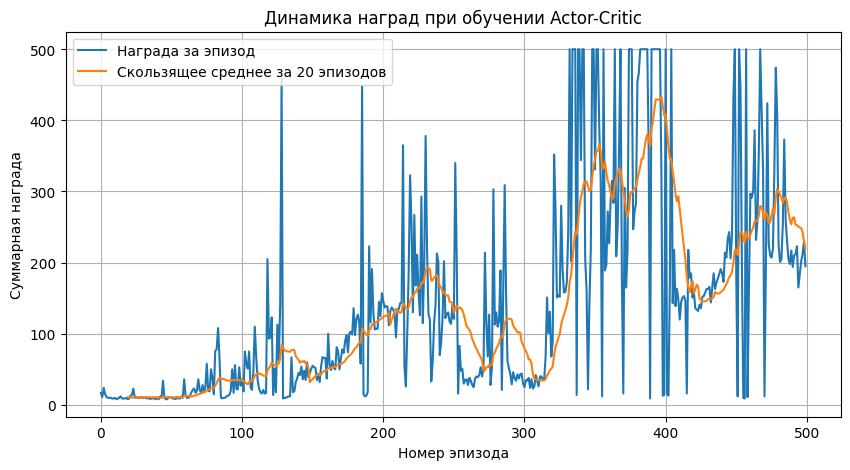

In [7]:
# Построение графика наград при обучении Actor-Critic

plt.figure(figsize=(10, 5))

plt.plot(ac_agent.episodes_reward, label="Награда за эпизод")

moving_average = pd.Series(ac_agent.episodes_reward).rolling(20).mean()
plt.plot(moving_average, label="Скользящее среднее за 20 эпизодов")

plt.title("Динамика наград при обучении Actor-Critic")
plt.xlabel("Номер эпизода")
plt.ylabel("Суммарная награда")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Формирование итоговой таблицы результатов лабораторной работы

final_results = pd.DataFrame({
    "Показатель": [
        "Среда",
        "Алгоритм",
        "Количество признаков состояния",
        "Количество действий",
        "Количество эпизодов обучения",
        "Время обучения",
        "Средняя награда за последние 50 эпизодов",
        "Среднее количество шагов за последние 50 эпизодов",
        "Максимальная награда при обучении",
        "Количество тестовых эпизодов",
        "Средняя тестовая награда",
        "Среднее количество шагов при тестировании",
        "Минимальная тестовая награда",
        "Максимальная тестовая награда"
    ],
    "Значение": [
        "CartPole-v1",
        "Actor-Critic",
        env.observation_space.shape[0],
        env.action_space.n,
        len(ac_agent.episodes_reward),
        training_time,
        np.mean(ac_agent.episodes_reward[-50:]),
        np.mean(ac_agent.episodes_steps[-50:]),
        np.max(ac_agent.episodes_reward),
        len(test_rewards),
        np.mean(test_rewards),
        np.mean(test_steps),
        np.min(test_rewards),
        np.max(test_rewards)
    ]
})

final_results

,Показатель,Значение
0,Среда,CartPole-v1
1,Алгоритм,Actor-Critic
2,Количество признаков состояния,4
3,Количество действий,2
4,Количество эпизодов обучения,500
5,Время обучения,245.323019
6,Средняя награда за последние 50 эпизодов,250.1
7,Среднее количество шагов за последние 50 эпизодов,250.1
8,Максимальная награда при обучении,500.0
9,Количество тестовых эпизодов,20
